In [1]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

file_path = "/kaggle/input/flight-delay-dataset-20182022/Combined_Flights_2018.csv"

df = pd.read_csv(file_path)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5689512 entries, 0 to 5689511
Data columns (total 61 columns):
 #   Column                                   Dtype  
---  ------                                   -----  
 0   FlightDate                               object 
 1   Airline                                  object 
 2   Origin                                   object 
 3   Dest                                     object 
 4   Cancelled                                bool   
 5   Diverted                                 bool   
 6   CRSDepTime                               int64  
 7   DepTime                                  float64
 8   DepDelayMinutes                          float64
 9   DepDelay                                 float64
 10  ArrTime                                  float64
 11  ArrDelayMinutes                          float64
 12  AirTime                                  float64
 13  CRSElapsedTime                           float64
 14  ActualElapsedTime 

In [3]:
df.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,...,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,...,1211.0,1249.0,7.0,1304,-8.0,0.0,-1.0,1300-1359,1,0.0
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,...,1210.0,1246.0,12.0,1304,-6.0,0.0,-1.0,1300-1359,1,0.0
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,False,False,1202,1153.0,0.0,-9.0,...,1211.0,1251.0,11.0,1304,-2.0,0.0,-1.0,1300-1359,1,0.0
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,False,False,1202,1150.0,0.0,-12.0,...,1207.0,1242.0,11.0,1304,-11.0,0.0,-1.0,1300-1359,1,0.0
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,False,False,1400,1355.0,0.0,-5.0,...,1412.0,1448.0,11.0,1500,-1.0,0.0,-1.0,1500-1559,1,0.0


In [4]:
missing = df.isnull().sum()
missing[missing > 1]


DepTime                  85380
DepDelayMinutes          86575
DepDelay                 86575
ArrTime                  90615
ArrDelayMinutes         102893
AirTime                 109271
CRSElapsedTime               6
ActualElapsedTime       102347
Tail_Number              20548
DepDel15                 86575
DepartureDelayGroups     86575
TaxiOut                  94694
WheelsOff                94684
WheelsOn                 97549
TaxiIn                   97559
ArrDelay                102893
ArrDel15                102893
ArrivalDelayGroups      102893
dtype: int64

In [5]:
cols_to_drop = [
    "DepDelay",
    "ArrDelayMinutes",
    "ArrDelay",
    "Tail_Number",
    "DepDel15",
    "DepartureDelayGroups",
    "TaxiOut",
    "WheelsOff",
    "WheelsOn",
    "TaxiIn",
    "ArrDel15",
    "ArrivalDelayGroups",
    'DOT_ID_Marketing_Airline',
    'IATA_Code_Marketing_Airline',
    'Flight_Number_Marketing_Airline',
    'DOT_ID_Operating_Airline',
    'IATA_Code_Operating_Airline',
    'Flight_Number_Operating_Airline',
    'OriginCityMarketID',
    'DestCityMarketID',
    'OriginAirportSeqID',
    'DestAirportSeqID',
    'OriginStateFips',
    'DestStateFips',
    'OriginWac',
    'DestWac',
    'Year'
]
d_C=df.copy()
d_C = d_C.drop(columns=cols_to_drop)


In [7]:
# DepTime
print("DepTime missing:", d_C["DepTime"].isna().sum())

# ArrTime
print("ArrTime missing:", d_C["ArrTime"].isna().sum())

# AirTime
print("AirTime missing:", d_C["AirTime"].isna().sum())

# ActualElapsedTime
print("ActualElapsedTime missing:", d_C["ActualElapsedTime"].isna().sum())

# CRSElapsedTime
print("CRSElapsedTime missing:", d_C["CRSElapsedTime"].isna().sum())


DepTime missing: 85380
ArrTime missing: 90615
AirTime missing: 109271
ActualElapsedTime missing: 102347
CRSElapsedTime missing: 6


In [8]:
# حذف الصفوف اللي فيها NaN في DepTime أو ArrTime
d_C = d_C[d_C["DepTime"].notna() & d_C["ArrTime"].notna()]

# التأكد من عدد الصفوف بعد الحذف
d_C.shape


(5598897, 34)

In [9]:
d_C.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5598897 entries, 0 to 5689511
Data columns (total 34 columns):
 #   Column                                   Dtype  
---  ------                                   -----  
 0   FlightDate                               object 
 1   Airline                                  object 
 2   Origin                                   object 
 3   Dest                                     object 
 4   Cancelled                                bool   
 5   Diverted                                 bool   
 6   CRSDepTime                               int64  
 7   DepTime                                  float64
 8   DepDelayMinutes                          float64
 9   ArrTime                                  float64
 10  AirTime                                  float64
 11  CRSElapsedTime                           float64
 12  ActualElapsedTime                        float64
 13  Distance                                 float64
 14  Quarter                

In [10]:
d_C.duplicated().sum()

0

In [11]:
d_C["FlightDate"] = pd.to_datetime(d_C["FlightDate"])


In [12]:
# Calculate actual flight delay in minutes
d_C["Delay"] = d_C["ActualElapsedTime"] - d_C["CRSElapsedTime"]

# 2️ Convert any negative values to zero
d_C["Delay"] = d_C["Delay"].clip(lower=0)

# 3️ Create a binary column for delayed flights
d_C["Delayed"] = (d_C["Delay"] >= 15).astype(int)

# 4️ Display counts of delayed vs on-time flights
print(d_C["Delayed"].value_counts())

# 5️ Show first 5 rows to verify
d_C.head()



Delayed
0    5232700
1     366197
Name: count, dtype: int64


,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,ArrTime,...,DestCityName,DestState,DestStateName,DepTimeBlk,CRSArrTime,ArrTimeBlk,DistanceGroup,DivAirportLandings,Delay,Delayed
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,1256.0,...,"Atlanta, GA",GA,Georgia,1200-1259,1304,1300-1359,1,0.0,0.0,0
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,1258.0,...,"Atlanta, GA",GA,Georgia,1200-1259,1304,1300-1359,1,0.0,0.0,0
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,False,False,1202,1153.0,0.0,1302.0,...,"Atlanta, GA",GA,Georgia,1200-1259,1304,1300-1359,1,0.0,7.0,0
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,False,False,1202,1150.0,0.0,1253.0,...,"Atlanta, GA",GA,Georgia,1200-1259,1304,1300-1359,1,0.0,1.0,0
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,False,False,1400,1355.0,0.0,1459.0,...,"Atlanta, GA",GA,Georgia,1400-1459,1500,1500-1559,1,0.0,4.0,0


In [13]:
# ==========================
# 1️⃣ Convert departure times to minutes
# ==========================
# Convert actual departure time from HHMM to total minutes
d_C["Dep_mins"] = (d_C["DepTime"] // 100) * 60 + (d_C["DepTime"] % 100)
# Convert scheduled departure time from HHMM to total minutes
d_C["CRSDep_mins"] = (d_C["CRSDepTime"] // 100) * 60 + (d_C["CRSDepTime"] % 100)

# Calculate actual departure delay in minutes
d_C["DepDelay"] = d_C["Dep_mins"] - d_C["CRSDep_mins"]
# Replace negative values with 0 (departed earlier than scheduled)
d_C["DepDelay"] = d_C["DepDelay"].apply(lambda x: x if x > 0 else 0)

# ==========================
# 2️⃣ Convert arrival times to minutes
# ==========================
# Convert actual arrival time from HHMM to total minutes
d_C["Arr_mins"] = (d_C["ArrTime"] // 100) * 60 + (d_C["ArrTime"] % 100)
# Convert scheduled arrival time from HHMM to total minutes
d_C["CRSArr_mins"] = (d_C["CRSArrTime"] // 100) * 60 + (d_C["CRSArrTime"] % 100)

# Calculate actual arrival delay in minutes
d_C["ArrDelay"] = d_C["Arr_mins"] - d_C["CRSArr_mins"]
# Replace negative values with 0 (arrived earlier than scheduled)
d_C["ArrDelay"] = d_C["ArrDelay"].apply(lambda x: x if x > 0 else 0)


Cancelled = True → flight was cancelled.

Diverted = True → flight landed at a different airport than planned.

value_counts() gives you the total number of True/False for each column.

In [15]:
# ==========================
# 1️⃣ Count the number of cancelled flights
# ==========================
# 'Cancelled' is a boolean column: True if the flight was cancelled, False otherwise
print(d_C["Cancelled"].value_counts())

# ==========================
# 2️⃣ Count the number of diverted flights
# ==========================
# 'Diverted' is a boolean column: True if the flight was diverted, False otherwise
print(d_C["Diverted"].value_counts())


Cancelled
False    5598888
True           9
Name: count, dtype: int64
Diverted
False    5587174
True       11723
Name: count, dtype: int64


Delay = ActualElapsedTime - CRSElapsedTime (actual flight time minus scheduled flight time).

All negative delays have been set to 0, so now:

Delay = 0 → Flight arrived on-time or earlier than scheduled.

Delay > 0 → Flight was delayed (took longer than scheduled).

The describe() output shows:

count → Total number of flights.

mean → Average delay in minutes.

std → Standard deviation of delays.

min → Minimum delay (0 after adjustment).

25%, 50%, 75% → Quartiles of delay distribution.

max → Maximum delay observed.

In [16]:
d_C["Delay"].describe()  # يعطيك إحصائيات: متوسط، أقصى، أدنى


count    5.587165e+06
mean     3.004788e+00
std      8.307262e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      4.750000e+02
Name: Delay, dtype: float64

In [17]:
# متوسط التأخير لكل شركة تشغيل
d_C.groupby("Operating_Airline")["Delay"].mean().sort_values(ascending=False)


Operating_Airline
KS    6.508475
C5    4.477158
VX    4.218621
AS    4.214679
AX    3.926188
EV    3.904615
MQ    3.899090
YX    3.882212
ZW    3.810558
OO    3.810208
AA    3.795803
B6    3.708925
UA    3.576990
YV    3.528544
F9    3.489913
CP    3.193532
PT    3.185757
G7    3.121707
9E    3.044110
NK    3.002814
QX    2.979437
G4    2.854273
HA    2.689655
OH    2.658761
EM    2.424166
9K    2.301511
DL    2.147134
WN    1.621507
Name: Delay, dtype: float64

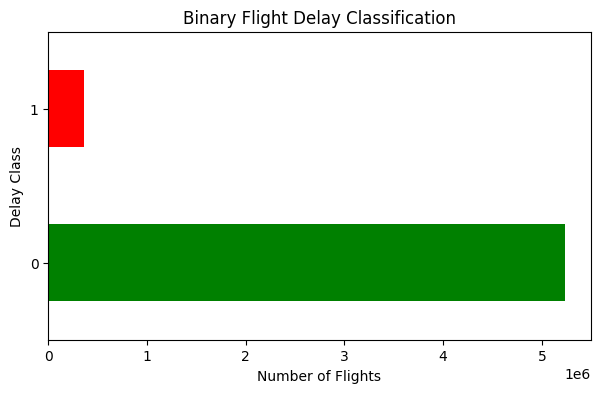

In [18]:

d_C["Delayed"].value_counts().plot(
    kind="barh",
    figsize=(7,4),
    color=["green", "red"],
    title="Binary Flight Delay Classification"
)
plt.xlabel("Number of Flights")
plt.ylabel("Delay Class")
plt.show()


"Scatter plot showing the relationship between departure delays and arrival delays. Most flights cluster around zero delay, while extreme outliers indicate data errors or unusually long/short flights."

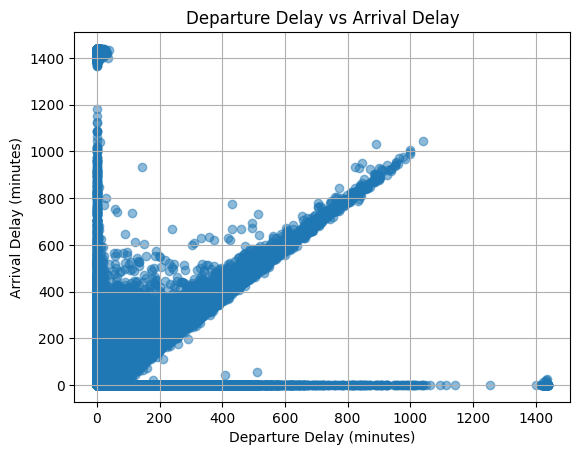

,DepDelay,ArrDelay
DepDelay,1.0000,0.3328
ArrDelay,0.3328,1.0000


In [19]:
plt.scatter(d_C['DepDelay'], d_C['ArrDelay'], alpha=0.5)
plt.title('Departure Delay vs Arrival Delay')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Arrival Delay (minutes)')
plt.grid(True)
plt.show()
d_C[['DepDelay','ArrDelay']].corr()

**This plot shows the number of flights in 2018 categorized by delay severity,On Time/Early, Small, Medium,Large Delays, and Cancelled,highlighting that most flights departed on time or with only minimal delays.**

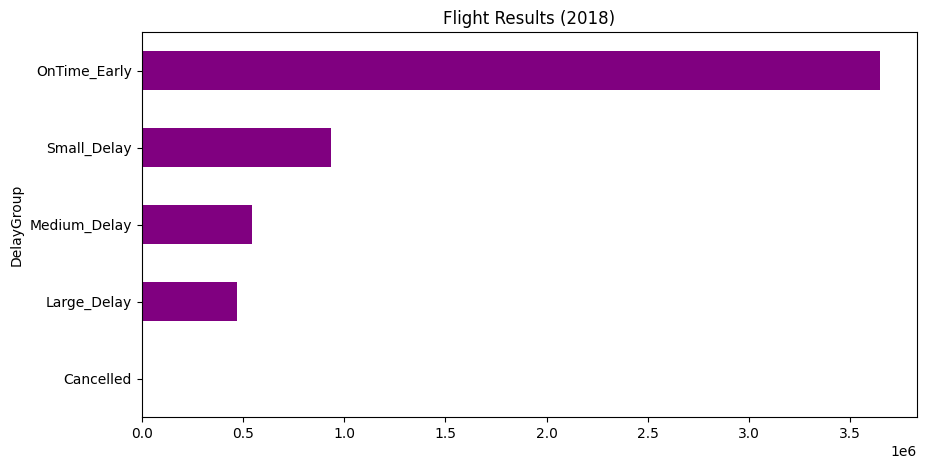

In [20]:
pal = sns.color_palette()
d_C["DelayGroup"] = None
d_C.loc[df["DepDelayMinutes"] == 0, "DelayGroup"] = "OnTime_Early"
d_C.loc[
    (d_C["DepDelayMinutes"] > 0) & (d_C["DepDelayMinutes"] <= 15), "DelayGroup"
] = "Small_Delay"
d_C.loc[
    (d_C["DepDelayMinutes"] > 15) & (d_C["DepDelayMinutes"] <= 45), "DelayGroup"
] = "Medium_Delay"
d_C.loc[d_C["DepDelayMinutes"] > 45, "DelayGroup"] = "Large_Delay"
d_C.loc[d_C["Cancelled"], "DelayGroup"] = "Cancelled"

d_C["DelayGroup"].value_counts(ascending=True).plot(
    kind="barh", figsize=(10, 5), color='purple', title="Flight Results (2018)"
)
plt.show()

**This plot shows how flight frequency varies across the days of the week, revealing that weekdays generally have more flights than weekends.**

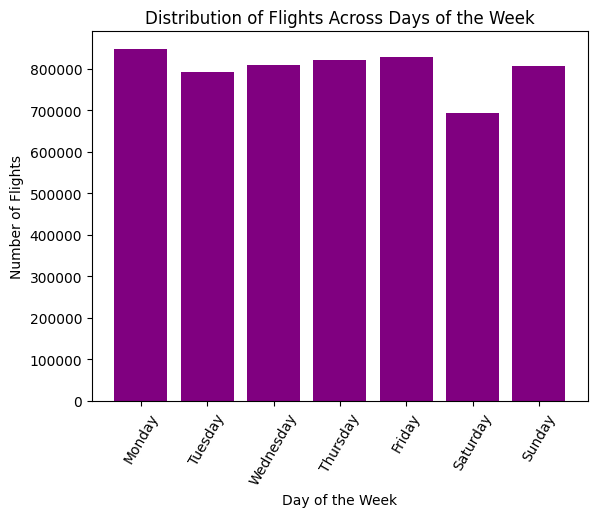

DayOfWeek
1    860802
2    807136
3    823966
4    836891
5    842255
6    701328
7    817134
Name: count, dtype: int64

In [21]:
# Count the occurrences of flights for each day of the week
day_of_week_counts = d_C['DayOfWeek'].value_counts().sort_index()

# Plotting a bar chart to visualize the distribution of flights across days of the week
plt.bar(day_of_week_counts.index, day_of_week_counts.values,color='purple')
plt.title('Distribution of Flights Across Days of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Flights')
plt.xticks(range(1, 8), ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], rotation=60)
plt.show()
df['DayOfWeek'].value_counts().sort_index()

The chart shows the distribution of flight delays: most flights arrive on time or with minor delays, while a very small number of flights experience long delays.

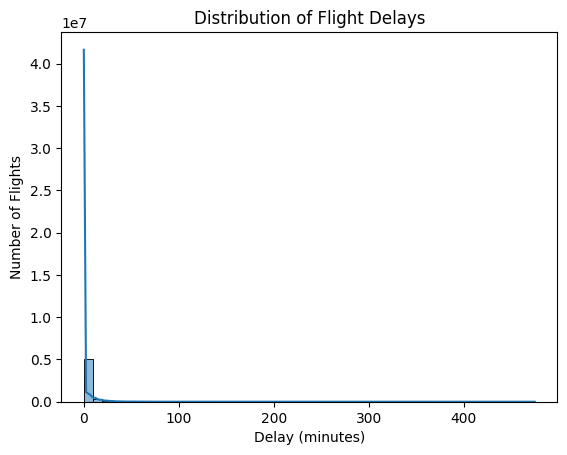

In [22]:

sns.histplot(d_C["Delay"], bins=50, kde=True)
plt.title("Distribution of Flight Delays")
plt.xlabel("Delay (minutes)")
plt.ylabel("Number of Flights")
plt.show()


KS has the highest delay rate, with about 15% of its flights delayed.

Airlines like VX, C5, and AS have delay rates around 10%.

Most other airlines have delay rates below 10%, with EM and 9K having the lowest, under 3%.

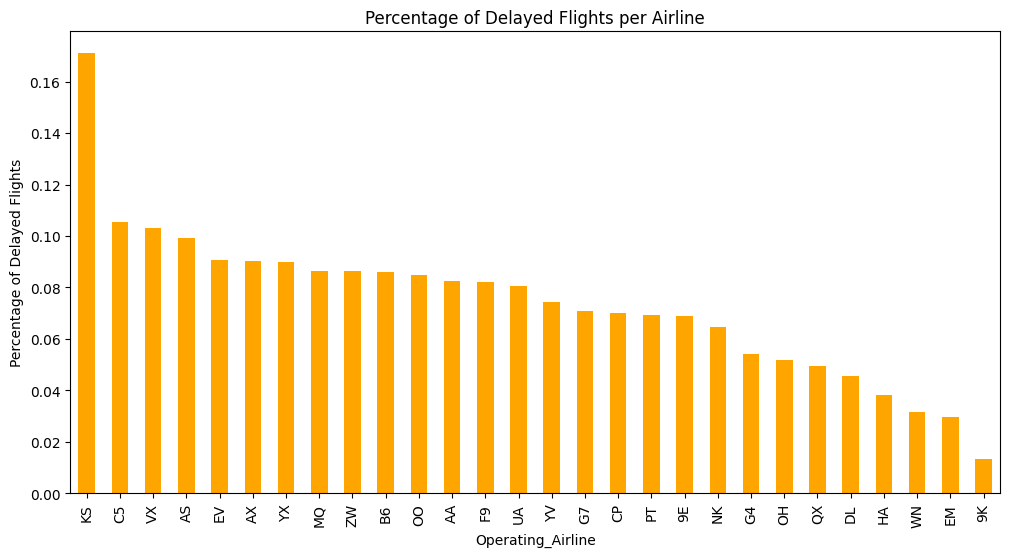

In [23]:
delayed_ratio = d_C.groupby("Operating_Airline")["Delayed"].mean().sort_values(ascending=False)
delayed_ratio.plot(kind="bar", figsize=(12,6), color="orange")
plt.ylabel("Percentage of Delayed Flights")
plt.title("Percentage of Delayed Flights per Airline")
plt.show()


The airport YNG has the highest delay rate, with more than 50% of its flights delayed — meaning about half of all flights experience delays, which is significant.

Next is CYS, with a delay rate of around 24%.

The remaining airports have delay rates ranging between 14% and 20%.

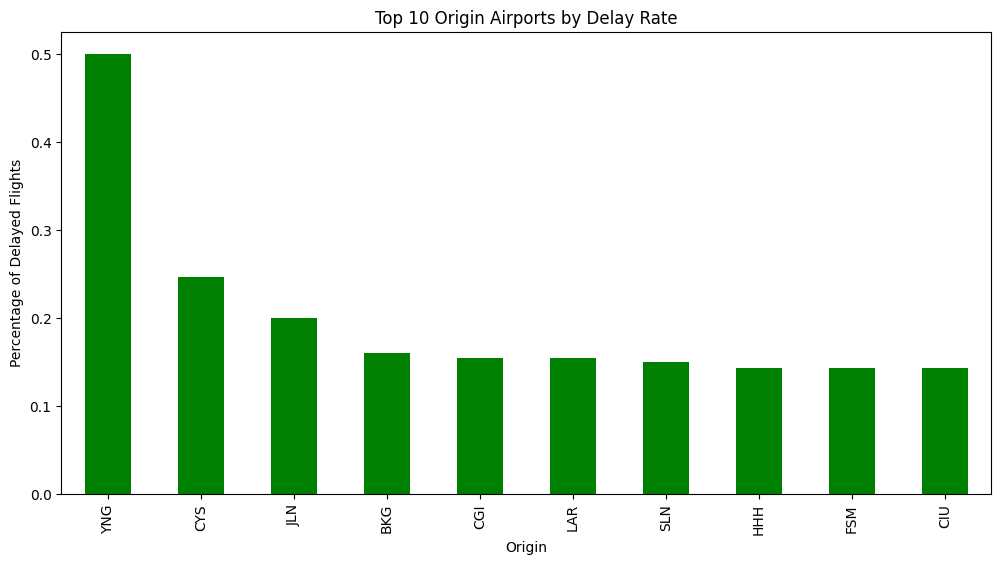

In [24]:
top_origins = d_C.groupby("Origin")["Delayed"].mean().sort_values(ascending=False).head(10)
top_origins.plot(kind="bar", figsize=(12,6), color="green")
plt.ylabel("Percentage of Delayed Flights")
plt.title("Top 10 Origin Airports by Delay Rate")
plt.show()


This chart shows the top 10 flight routes with the highest delay rates.
Each bar represents a route from one airport to another with a specific airline.
The darker the color, the higher the delay percentage.
The top route has the most delays, and the rest are shown in descending order.

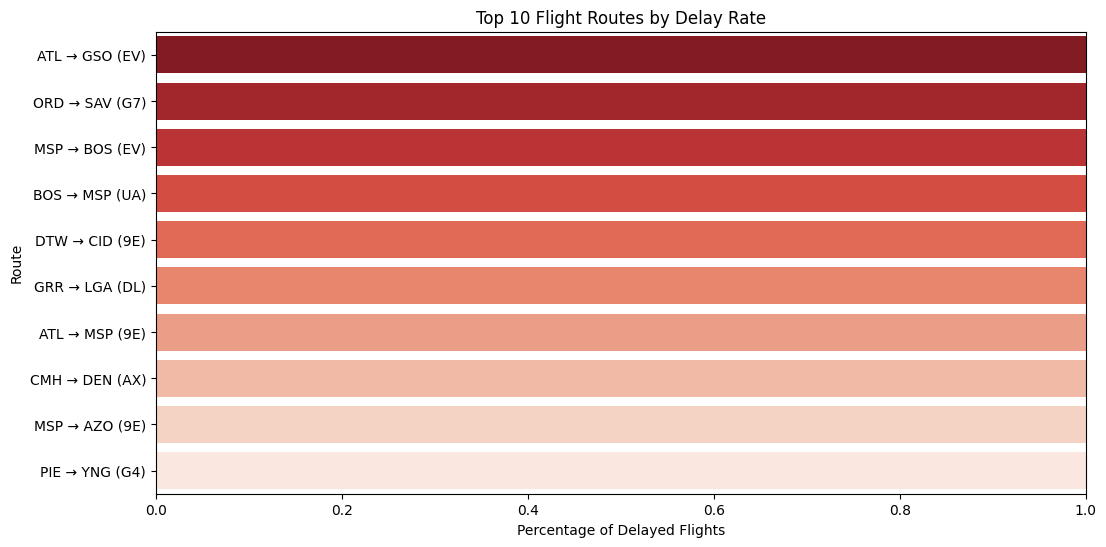

In [25]:

top_routes = d_C.groupby(["Operating_Airline", "Origin", "Dest"])["Delayed"].mean().sort_values(ascending=False).head(10)

top_routes_df = top_routes.reset_index()
top_routes_df["Route"] = top_routes_df["Origin"] + " → " + top_routes_df["Dest"] + " (" + top_routes_df["Operating_Airline"] + ")"

plt.figure(figsize=(12,6))
sns.barplot(x="Delayed", y="Route", data=top_routes_df, palette="Reds_r")
plt.xlabel("Percentage of Delayed Flights")
plt.ylabel("Route")
plt.title("Top 10 Flight Routes by Delay Rate")
plt.xlim(0,1)
plt.show()


**Extra**

**Which distance group has the most flights?**

<Axes: xlabel='DistanceGroup', ylabel='count'>

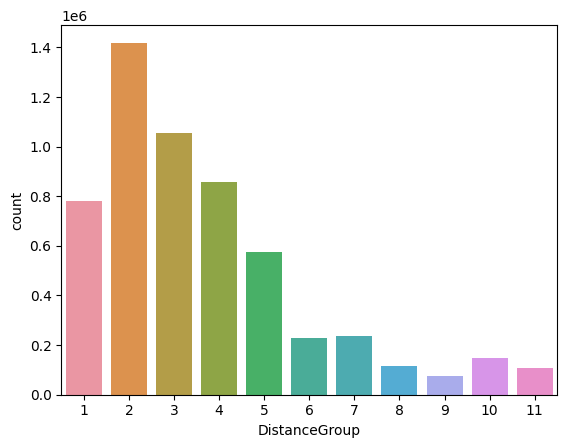

In [26]:
sns.countplot(data=d_C,x='DistanceGroup')

**Which distance group of flights experiences the highest delay rate? Does the distance of the flight seem to affect the likelihood of being delayed?**

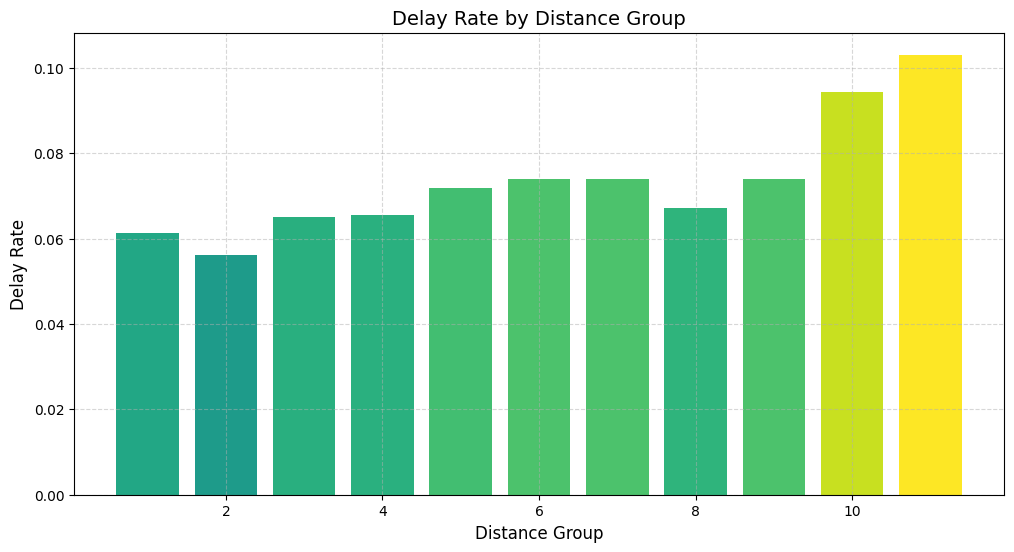

In [27]:
import matplotlib.cm as cm

delayed_counts = d_C[d_C['Delayed']==True].groupby('DistanceGroup')['Delayed'].count()

total_counts = d_C.groupby('DistanceGroup')['Delayed'].count()

delay_rate = delayed_counts / total_counts

colors = cm.viridis(delay_rate / delay_rate.max())

plt.figure(figsize=(12,6))
bars = plt.bar(delay_rate.index, delay_rate, color=colors)
plt.title('Delay Rate by Distance Group', fontsize=14)
plt.xlabel('Distance Group', fontsize=12)
plt.ylabel('Delay Rate', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

**How does the number of flights vary throughout the year? Which months have the highest and lowest flight activity?**

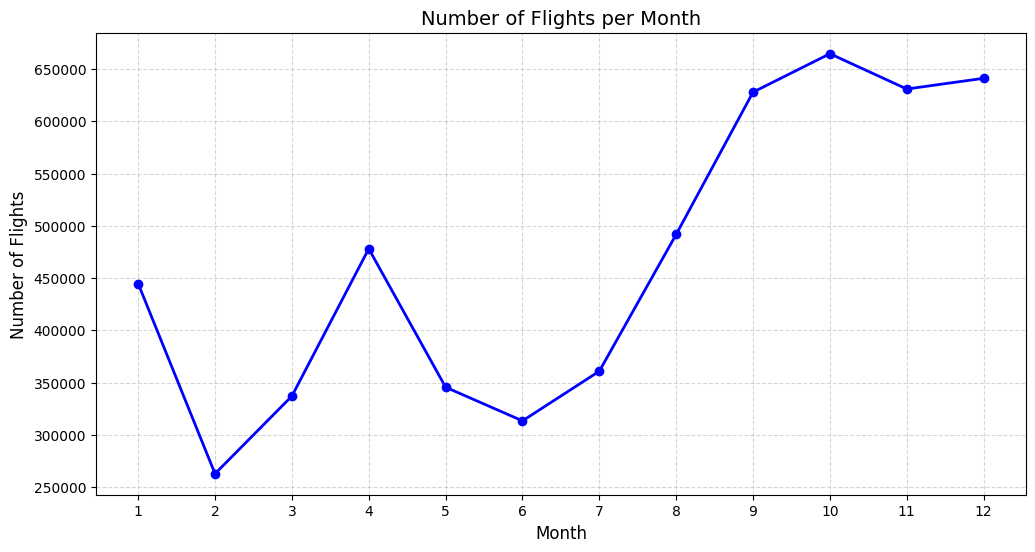

In [28]:

monthly_counts = d_C.groupby('Month').size()

plt.figure(figsize=(12,6))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o', linestyle='-', color='blue', linewidth=2)

plt.xticks(monthly_counts.index)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Flights", fontsize=12)
plt.title("Number of Flights per Month", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)



plt.show()


**Which quarter had the highest number of diverted flights? What might be the reason for these diversions?**

<Axes: xlabel='Quarter,Diverted'>

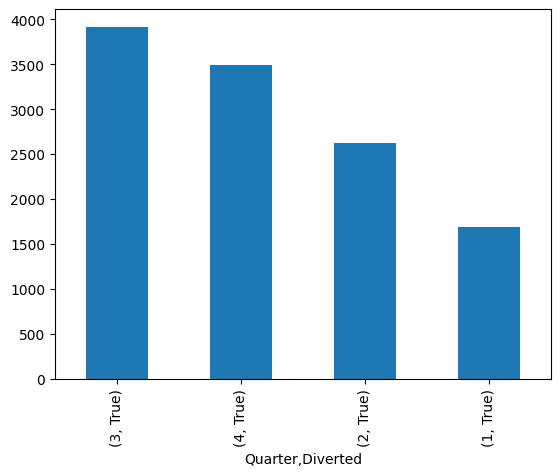

In [29]:

d_C[d_C['Diverted']==True].groupby('Quarter')['Diverted'].value_counts().sort_values(ascending=False).plot(kind='bar')

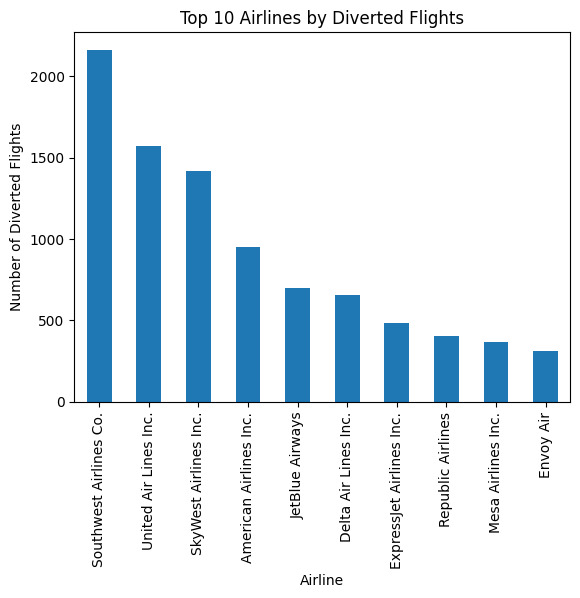

In [30]:
d_C[d_C['Diverted']==True].groupby('Airline')['Diverted'].count().sort_values(ascending=False).head(10).plot(kind='bar')
plt.ylabel("Number of Diverted Flights")
plt.xlabel("Airline")
plt.title("Top 10 Airlines by Diverted Flights")
plt.show()


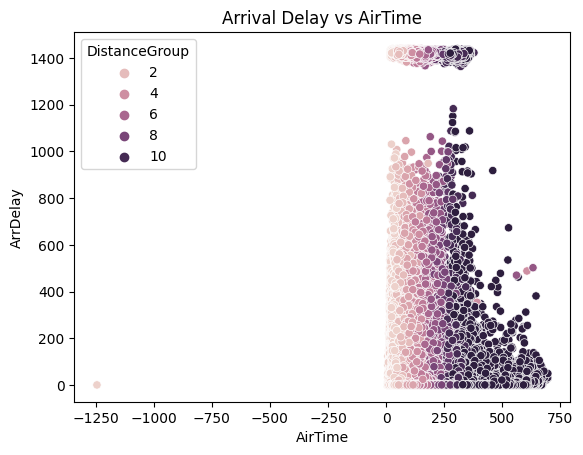

In [31]:
sns.scatterplot(data=d_C, x='AirTime', y='ArrDelay', hue='DistanceGroup')
plt.title("Arrival Delay vs AirTime")
plt.show()


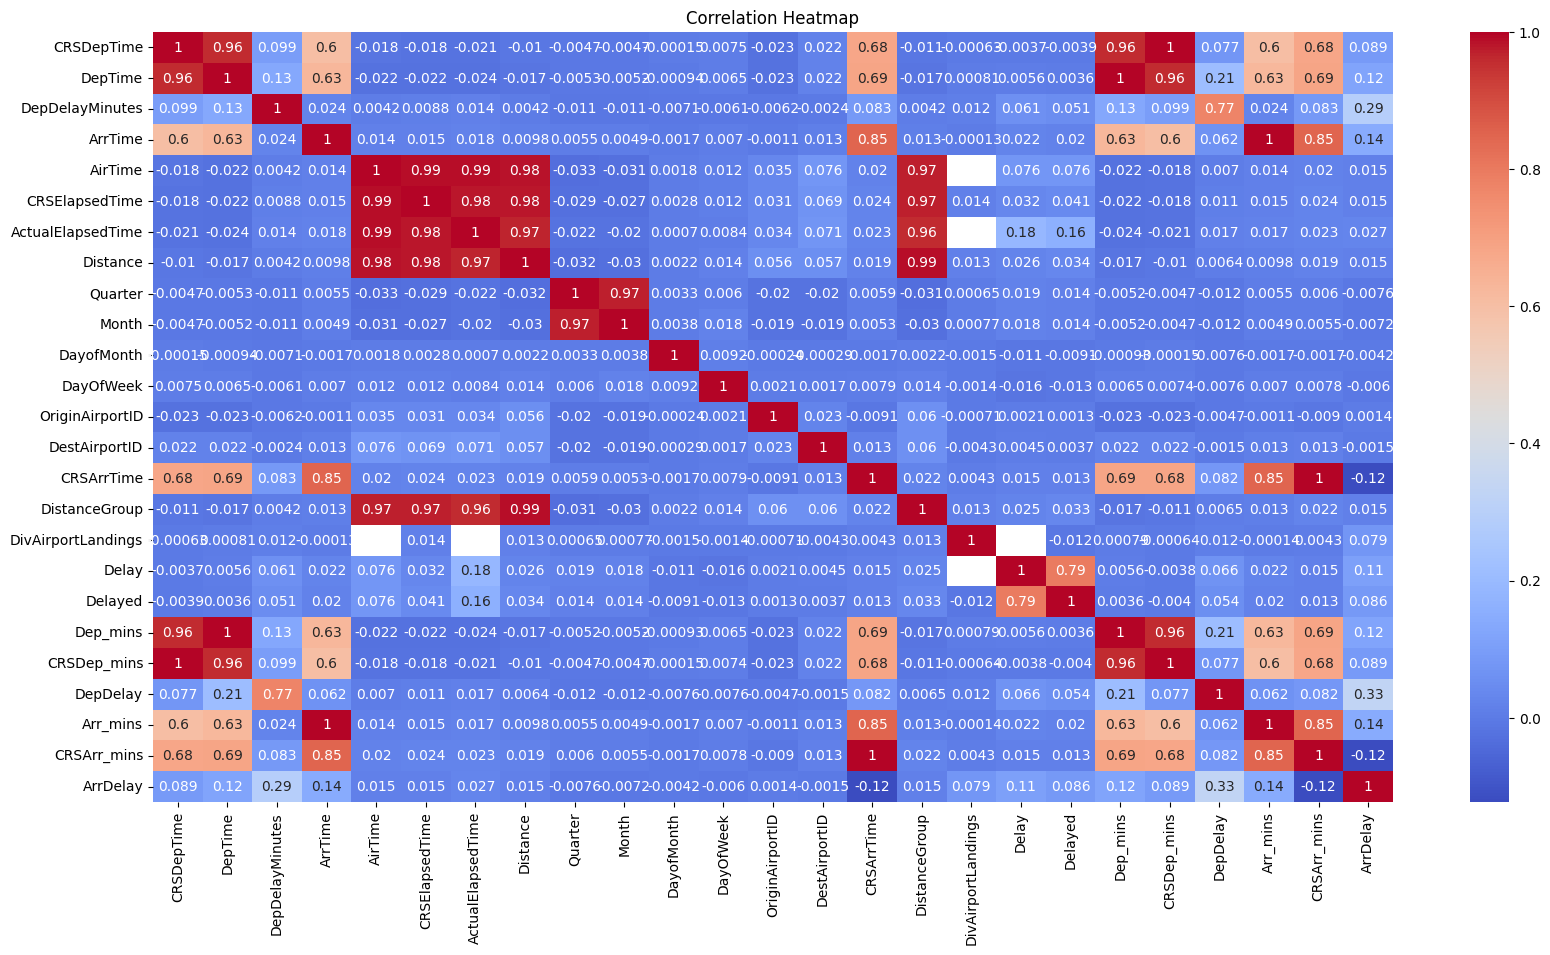

In [32]:
numeric_df = d_C.select_dtypes(include=[np.number])
plt.figure(figsize=(20,10))
sns.heatmap(numeric_df.corr(),annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [34]:
d_C['Cancelled'] = d_C['Cancelled'].astype(int)
d_C['Diverted'] = d_C['Diverted'].astype(int)

print(d_C[['Cancelled', 'Diverted']].head())


   Cancelled  Diverted
0          0         0
1          0         0
2          0         0
3          0         0
4          0         0


In [35]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [36]:
# Show only columns with missing values
missing = d_C.isnull().sum()
missing = missing[missing > 0]
print(missing)


DepDelayMinutes       1118
AirTime              18656
CRSElapsedTime           3
ActualElapsedTime    11732
Delay                11732
DelayGroup            1109
dtype: int64


**If you want to use all data without losing any, missing values in numeric columns will be filled using imputation.**

In [92]:
numeric_cols = d_C.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Delayed' in numeric_cols:
    numeric_cols.remove('Delayed')


X = d_C[numeric_cols]
y = d_C['Delayed']


**Imputation**

In [93]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

d_C[numeric_cols] = imputer.fit_transform(d_C[numeric_cols])

X = d_C[numeric_cols]
y = d_C['Delayed']

**If you prefer not to, columns containing missing values will be excluded before training.**

In [94]:
numeric_cols = d_C.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Delayed' in numeric_cols:
    numeric_cols.remove('Delayed')

cols_to_exclude = ['AirTime', 'CRSElapsedTime', 'ActualElapsedTime', 'Delay']
numeric_cols = [col for col in numeric_cols if col not in cols_to_exclude]

X = d_C[numeric_cols]
y = d_C['Delayed']


In [95]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**to check if we need Scaling or nah**

In [96]:
X.describe()


,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,ArrTime,Distance,Quarter,Month,DayofMonth,...,DestAirportID,CRSArrTime,DistanceGroup,DivAirportLandings,Dep_mins,CRSDep_mins,DepDelay,Arr_mins,CRSArr_mins,ArrDelay
count,147709.0,147709.000000,147709.000000,147709.000000,147709.000000,147709.000000,147709.000000,147709.000000,147709.00000,147709.000000,...,147709.000000,147709.000000,147709.000000,147709.000000,147709.000000,147709.000000,147709.000000,147709.000000,147709.000000,147709.000000
mean,0.0,0.001693,1328.962291,1334.274046,12.016180,1477.286103,766.268623,3.221835,8.01069,15.876852,...,12684.113209,1490.635913,3.541132,0.001720,812.762154,808.183462,11.223967,898.198844,906.046483,15.245977
std,0.0,0.041106,486.651654,497.266423,42.439857,525.425373,583.006648,1.314902,4.17114,8.833491,...,1522.791312,511.097801,2.304250,0.042081,298.089648,292.754777,36.763272,315.406737,306.866197,84.484519
min,0.0,0.000000,1.000000,1.000000,0.000000,1.000000,16.000000,1.000000,1.00000,1.000000,...,10135.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,0.0,0.000000,915.000000,921.000000,0.000000,1057.000000,340.000000,1.000000,1.00000,8.000000,...,11292.000000,1105.000000,2.000000,0.000000,561.000000,555.000000,0.000000,657.000000,665.000000,0.000000
50%,0.0,0.000000,1321.000000,1330.000000,0.000000,1511.000000,602.000000,4.000000,10.00000,16.000000,...,12889.000000,1515.000000,3.000000,0.000000,810.000000,801.000000,0.000000,911.000000,915.000000,0.000000
75%,0.0,0.000000,1732.000000,1740.000000,5.000000,1915.000000,997.000000,4.000000,11.00000,24.000000,...,14057.000000,1916.000000,4.000000,0.000000,1060.000000,1052.000000,5.000000,1155.000000,1156.000000,6.000000
max,0.0,1.000000,2359.000000,2400.000000,1573.000000,2400.000000,4983.000000,4.000000,11.00000,31.000000,...,16218.000000,2400.000000,11.000000,2.000000,1440.000000,1439.000000,1438.000000,1440.000000,1440.000000,1437.000000


In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**to check about imbalance**

In [98]:
print(y.value_counts())
print(y.value_counts(normalize=True))


Delayed
0    138065
1      9644
Name: count, dtype: int64
Delayed
0    0.934709
1    0.065291
Name: proportion, dtype: float64


In [99]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts(normalize=True))
print("After SMOTE:\n", y_train_res.value_counts(normalize=True))


Before SMOTE:
 Delayed
0    0.934923
1    0.065077
Name: proportion, dtype: float64
After SMOTE:
 Delayed
0    0.5
1    0.5
Name: proportion, dtype: float64
